In [1]:
%cd nanoVLM

import gymnasium as gym
from minigrid.envs.empty import EmptyEnv
import numpy as np
import torch
from PIL import Image

from data.processors import get_image_processor, get_image_string
from data.emptyenv_action_dataset import DEFAULT_PROMPT

from models.vision_language_model_action import VisionLanguageActionModel
import models.config as config
from data.emptyenv_action_dataset import DEFAULT_PROMPT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# загружаем конфиг
vlm_cfg = config.VLMConfig()
# загружаем модель

vlm_cfg.max_img_size = 512
#model = VisionLanguageActionModel(vlm_cfg, load_backbone=True, num_actions=3)
model = VisionLanguageActionModel.from_pretrained("/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_action/base_sft/step_30")
#model = VisionLanguageActionModel.from_pretrained("/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_grpo/it_10")

model.to(device)
model.eval()

print("Model loaded.")



/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


/teamspace/studios/this_studio/nanoVLM-action/nanoVLM


Model loaded.


In [2]:
import torch
import numpy as np
from PIL import Image
from minigrid.envs.empty import EmptyEnv
from data.processors import get_image_processor, get_image_string
from data.emptyenv_action_dataset import DEFAULT_PROMPT
import matplotlib.pyplot as plt

ID2ACTION = {0: "left", 1: "right", 2: "forward"}
ACTION2ID = {"left": 0, "right": 1, "forward": 2}

device = next(model.parameters()).device

image_processor = get_image_processor(
    vlm_cfg.max_img_size,
    vlm_cfg.vit_img_size,
    vlm_cfg.resize_to_max_side_len
)
tokenizer = model.tokenizer


@torch.no_grad()
def policy_action_from_rgb(rgb, prompt=DEFAULT_PROMPT, temperature=1.0, greedy=False):
    """
    temperature > 1.0  -> more exploration (flatter probs)
    temperature < 1.0  -> more greedy (sharper probs)
    greedy=True        -> argmax regardless of temperature
    """
    img = Image.fromarray(rgb).convert("RGB")
    processed_image, splitted_image_count = image_processor(img)

    messages = [{"role": "user", "content": prompt}]
    image_string = get_image_string(tokenizer, [splitted_image_count], vlm_cfg.mp_image_token_length)
    messages[0]["content"] = image_string + messages[0]["content"]

    conv = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_special_tokens=False,
        return_dict=True,
    )

    input_ids = torch.tensor(conv["input_ids"], dtype=torch.long).unsqueeze(0).to(device)
    attention_mask = torch.tensor(conv["attention_mask"], dtype=torch.long).unsqueeze(0).to(device)
    images = [[processed_image]]  # batch size 1

    logits, _ = model(
        input_ids=input_ids,
        images=images,
        attention_mask=attention_mask,
        action_labels=None
    )  # logits: [1, 3]

    logits = logits[0]  # [3]

    if greedy:
        probs = torch.softmax(logits, dim=-1)
        action = int(torch.argmax(probs).item())
        return action, probs.detach().cpu().numpy()

    # Temperature sampling
    T = float(temperature)
    if T <= 0:
        raise ValueError("temperature must be > 0")

    probs = torch.softmax(logits / T, dim=-1)   # [3]
    action = int(torch.multinomial(probs, num_samples=1).item())
    return action, probs.detach().cpu().numpy()


def run_eval(num_episodes=20, sizes=[6, 7], max_steps=200, render=False, seed=0, temperature=1.0, greedy=False, show_env = False):
    successes = 0
    returns = []
    lengths = []

    rng = np.random.default_rng(seed)

    for ep in range(num_episodes):
        size = int(rng.choice(sizes))
        env = EmptyEnv(size=size, agent_start_pos=None, render_mode="rgb_array")
        obs, info = env.reset(seed=seed + ep)

        env.agent_dir = int(rng.integers(0, 4))

        ep_ret = 0.0
        ep_len = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            rgb = env.render()

            action, probs = policy_action_from_rgb(
                rgb,
                temperature=temperature,
                greedy=greedy
            )

            obs, reward, terminated, truncated, info = env.step(action)
            ep_ret += float(reward)
            ep_len += 1

            if render:
                print(f"ep={ep} t={ep_len} a={ID2ACTION[action]} probs={np.round(probs,3)}")
            if show_env:
                plt.figure(figsize=(4,4))
                plt.imshow(rgb)
                plt.axis("off")
                plt.show()

            if ep_len >= max_steps:
                break

        success = 1 if ep_ret > 0 else 0
        successes += success
        returns.append(ep_ret)
        lengths.append(ep_len)

        print(f"[EP {ep}] size={size} success={success} return={ep_ret:.2f} len={ep_len}")

        env.close()

    print("\n=== Summary ===")
    print(f"Success rate: {successes/num_episodes:.3f} ({successes}/{num_episodes})")
    print(f"Avg return:   {np.mean(returns):.3f}")
    print(f"Avg length:   {np.mean(lengths):.1f}")



# 1) exploration (temperature sampling)
# run_eval(num_episodes=100, sizes=[8], max_steps=100, render=False, seed=123, temperature=1.7, greedy=False) 

# run_eval(num_episodes=20, sizes=[8], max_steps=100, render=True, seed=123, greedy=True)

Resize to max side len: True


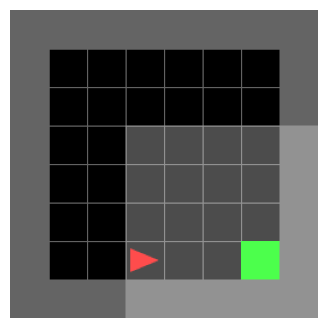

ep=41 t=40 a=forward probs=[0.073 0.042 0.885]


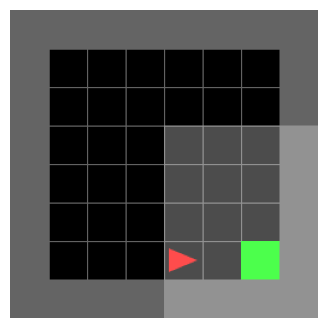

ep=41 t=41 a=forward probs=[0.042 0.052 0.906]


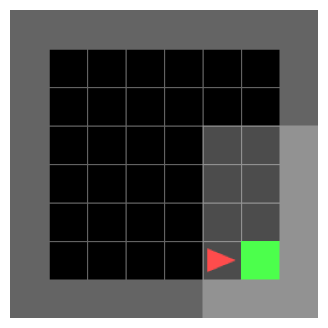

[EP 41] size=8 success=1 return=0.86 len=41
ep=42 t=1 a=forward probs=[0.046 0.021 0.933]


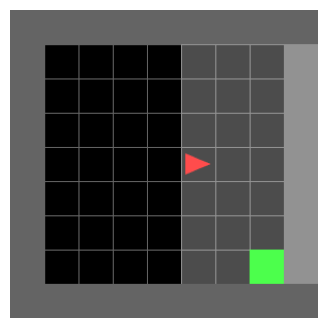

ep=42 t=2 a=forward probs=[0.039 0.023 0.938]


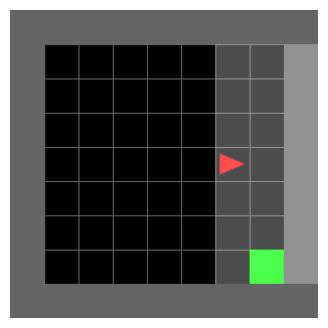

ep=42 t=3 a=forward probs=[0.055 0.038 0.907]


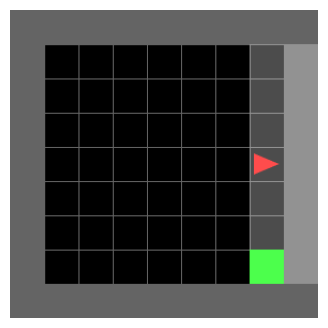

ep=42 t=4 a=forward probs=[0.055 0.038 0.907]


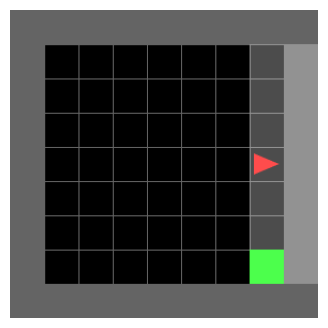

ep=42 t=5 a=forward probs=[0.055 0.038 0.907]


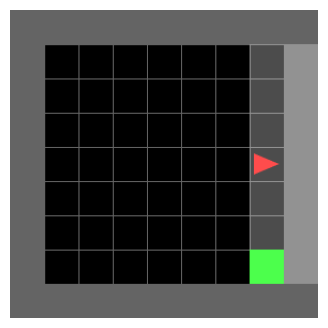

ep=42 t=6 a=forward probs=[0.055 0.038 0.907]


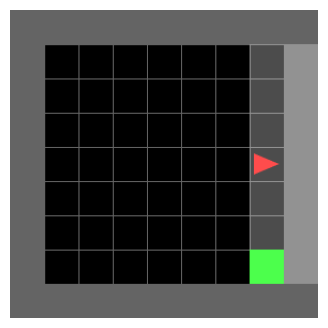

ep=42 t=7 a=forward probs=[0.055 0.038 0.907]


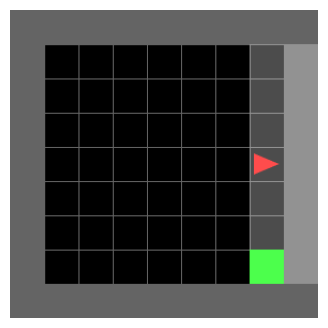

ep=42 t=8 a=forward probs=[0.055 0.038 0.907]


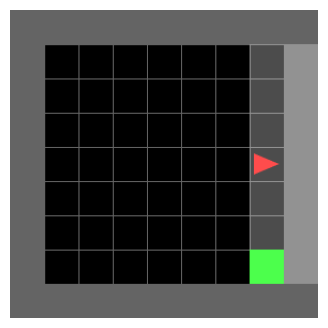

ep=42 t=9 a=forward probs=[0.055 0.038 0.907]


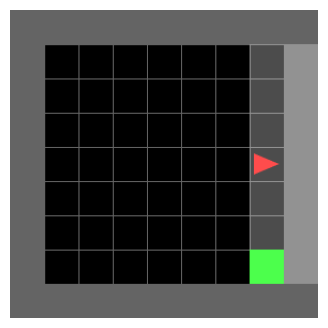

ep=42 t=10 a=forward probs=[0.055 0.038 0.907]


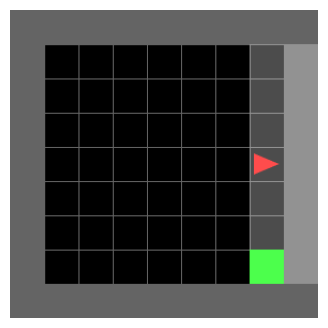

ep=42 t=11 a=forward probs=[0.055 0.038 0.907]


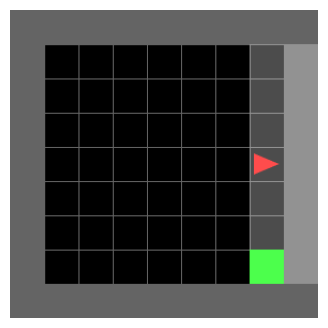

ep=42 t=12 a=forward probs=[0.055 0.038 0.907]


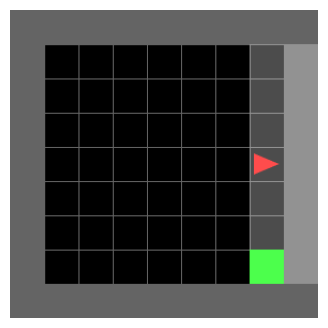

ep=42 t=13 a=forward probs=[0.055 0.038 0.907]


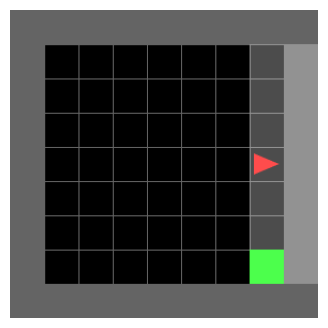

ep=42 t=14 a=forward probs=[0.055 0.038 0.907]


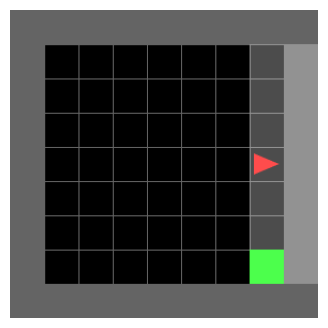

ep=42 t=15 a=forward probs=[0.055 0.038 0.907]


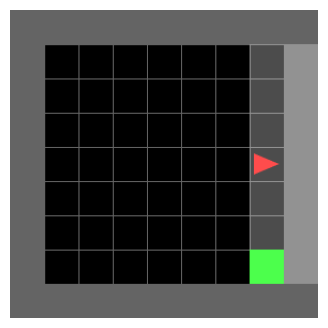

ep=42 t=16 a=forward probs=[0.055 0.038 0.907]


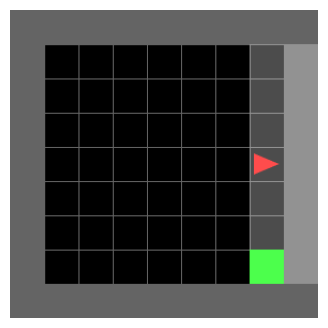

ep=42 t=17 a=forward probs=[0.055 0.038 0.907]


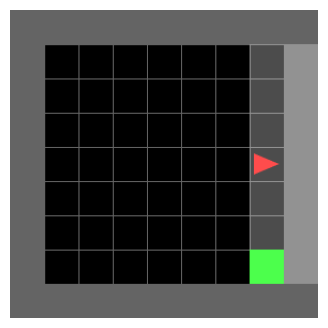

ep=42 t=18 a=forward probs=[0.055 0.038 0.907]


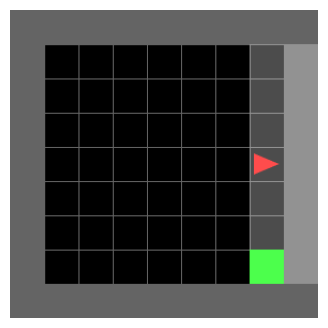

ep=42 t=19 a=forward probs=[0.055 0.038 0.907]


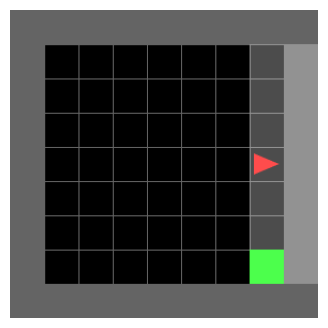

ep=42 t=20 a=right probs=[0.055 0.038 0.907]


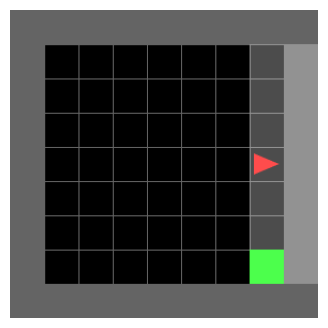

ep=42 t=21 a=forward probs=[0.097 0.07  0.833]


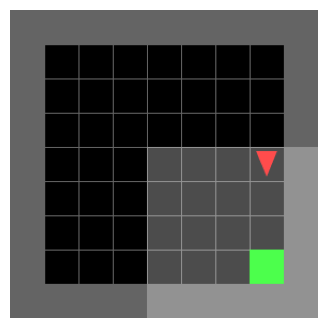

ep=42 t=22 a=forward probs=[0.079 0.031 0.89 ]


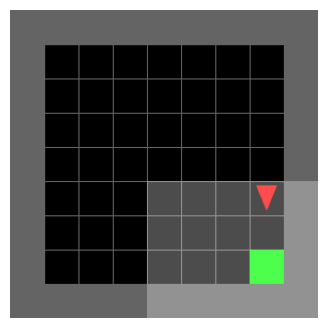

ep=42 t=23 a=forward probs=[0.047 0.04  0.913]


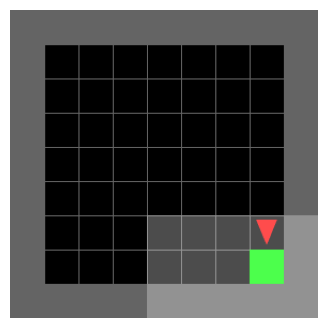

[EP 42] size=9 success=1 return=0.94 len=23
ep=43 t=1 a=forward probs=[0.041 0.034 0.925]


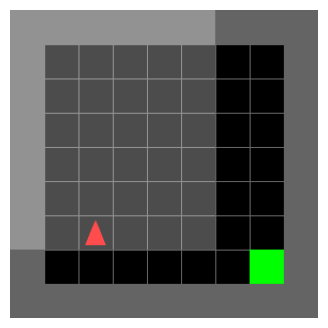

ep=43 t=2 a=forward probs=[0.067 0.019 0.915]


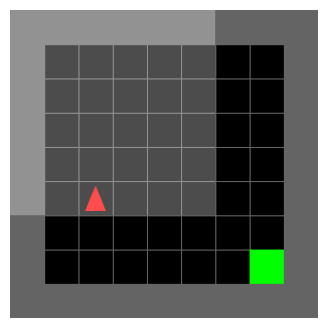

ep=43 t=3 a=forward probs=[0.053 0.029 0.918]


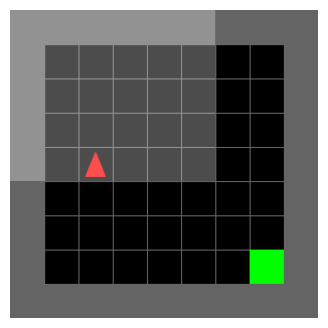

ep=43 t=4 a=forward probs=[0.086 0.049 0.864]


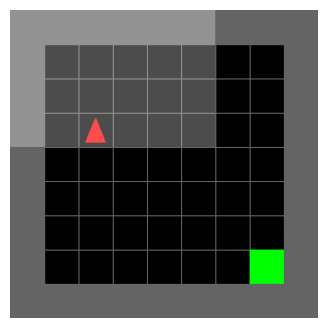

ep=43 t=5 a=forward probs=[0.093 0.053 0.854]


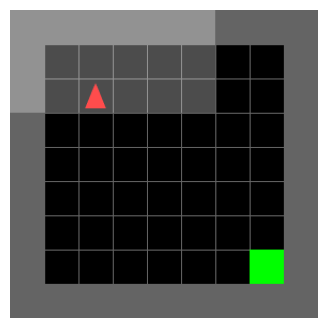

ep=43 t=6 a=forward probs=[0.075 0.029 0.896]


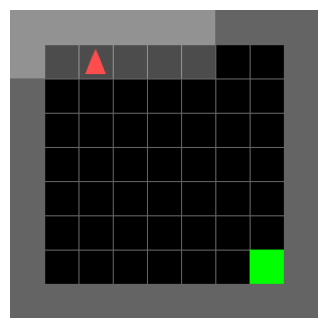

ep=43 t=7 a=forward probs=[0.075 0.029 0.896]


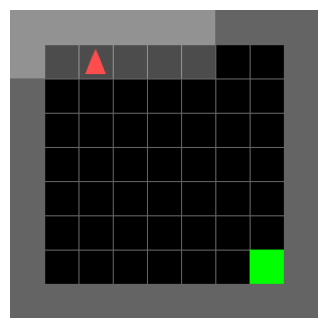

ep=43 t=8 a=forward probs=[0.075 0.029 0.896]


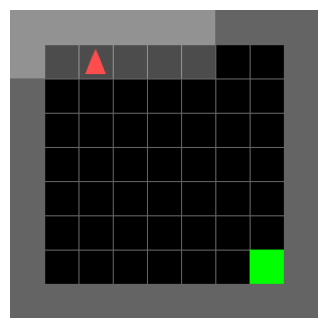

ep=43 t=9 a=forward probs=[0.075 0.029 0.896]


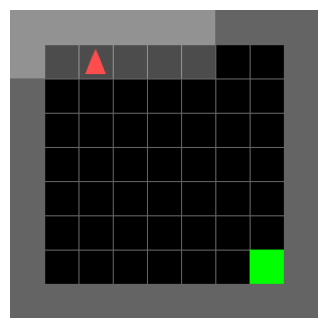

ep=43 t=10 a=forward probs=[0.075 0.029 0.896]


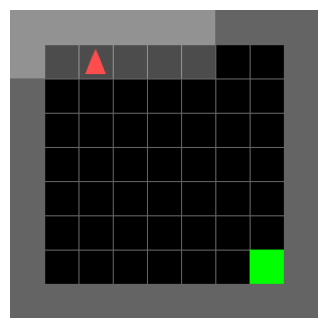

ep=43 t=11 a=forward probs=[0.075 0.029 0.896]


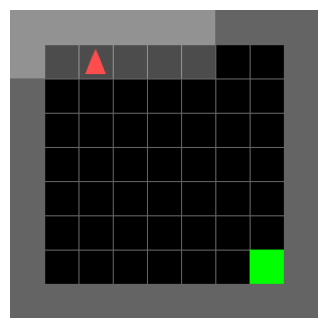

ep=43 t=12 a=right probs=[0.075 0.029 0.896]


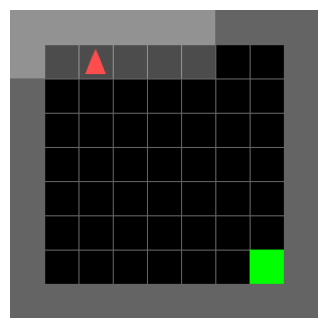

ep=43 t=13 a=forward probs=[0.116 0.057 0.827]


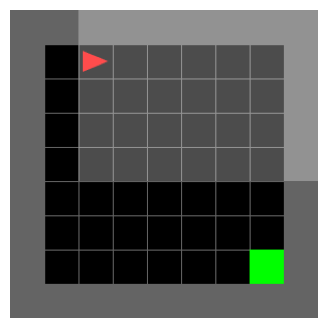

ep=43 t=14 a=forward probs=[0.117 0.03  0.853]


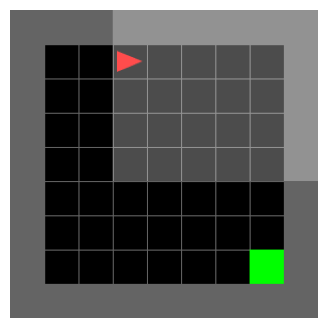

ep=43 t=15 a=forward probs=[0.106 0.028 0.866]


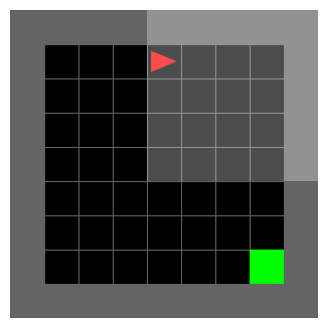

ep=43 t=16 a=forward probs=[0.092 0.018 0.89 ]


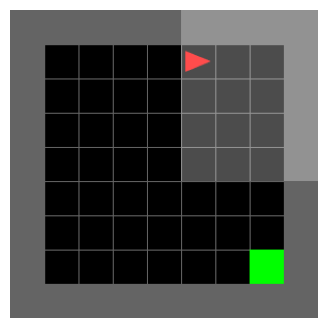

ep=43 t=17 a=forward probs=[0.039 0.03  0.931]


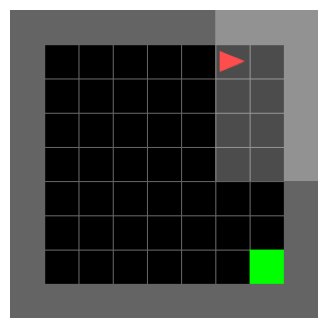

ep=43 t=18 a=forward probs=[0.097 0.049 0.854]


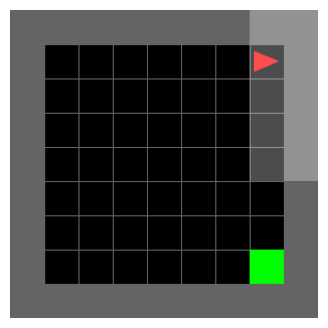

ep=43 t=19 a=right probs=[0.097 0.049 0.854]


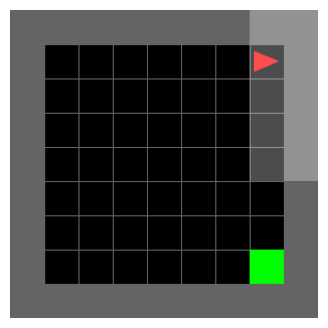

ep=43 t=20 a=forward probs=[0.067 0.041 0.892]


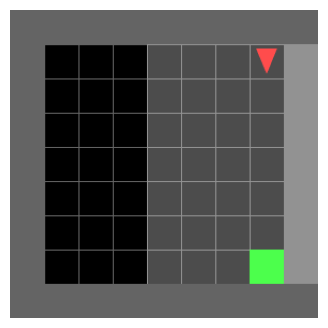

ep=43 t=21 a=forward probs=[0.059 0.043 0.898]


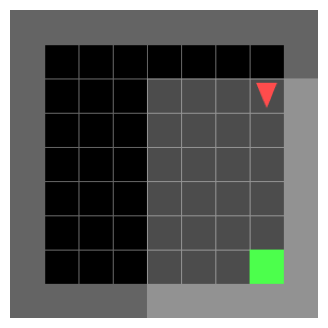

ep=43 t=22 a=forward probs=[0.098 0.062 0.84 ]


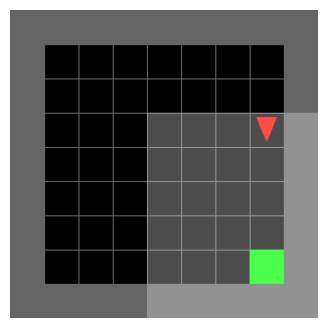

ep=43 t=23 a=left probs=[0.097 0.07  0.833]


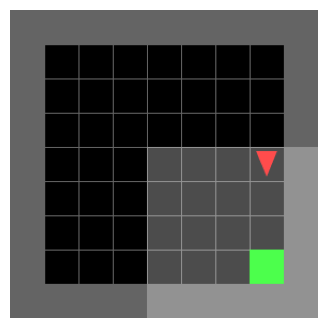

ep=43 t=24 a=forward probs=[0.055 0.038 0.907]


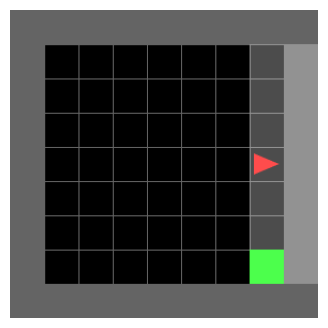

ep=43 t=25 a=forward probs=[0.055 0.038 0.907]


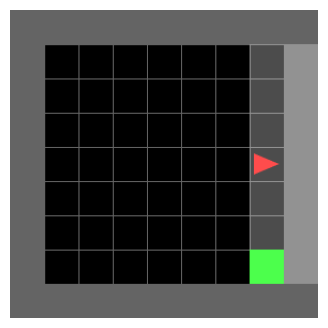

ep=43 t=26 a=forward probs=[0.055 0.038 0.907]


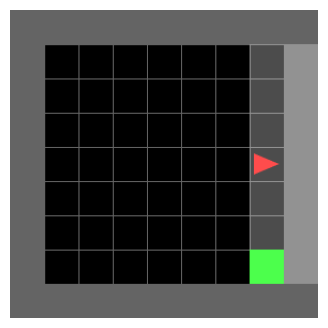

ep=43 t=27 a=forward probs=[0.055 0.038 0.907]


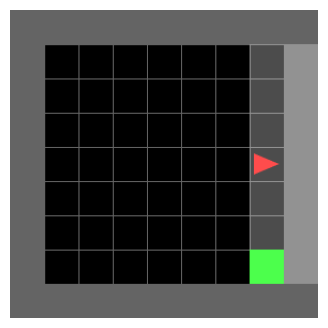

ep=43 t=28 a=forward probs=[0.055 0.038 0.907]


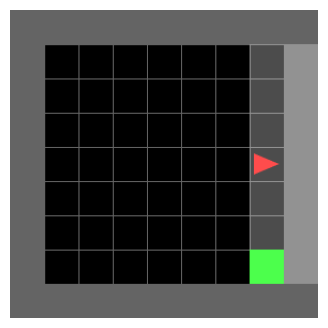

ep=43 t=29 a=forward probs=[0.055 0.038 0.907]


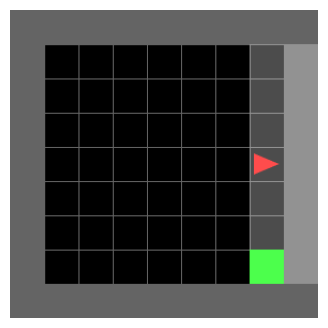

ep=43 t=30 a=left probs=[0.055 0.038 0.907]


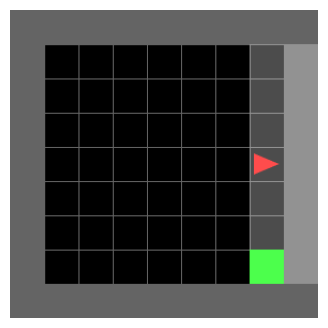

ep=43 t=31 a=left probs=[0.115 0.091 0.794]


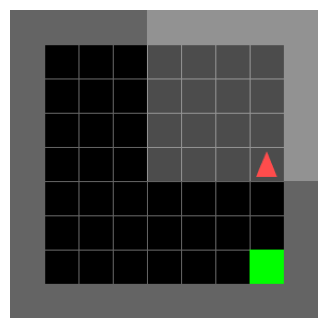

ep=43 t=32 a=forward probs=[0.056 0.034 0.911]


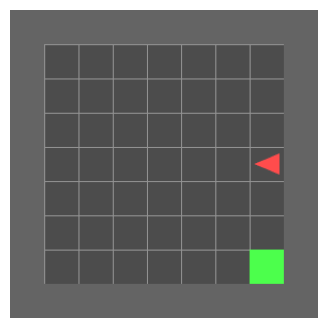

ep=43 t=33 a=forward probs=[0.041 0.023 0.937]


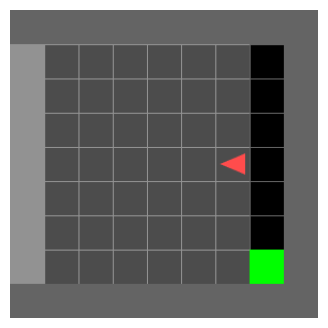

ep=43 t=34 a=forward probs=[0.022 0.014 0.963]


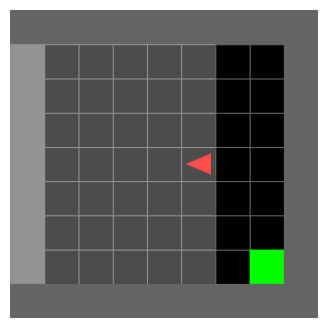

ep=43 t=35 a=forward probs=[0.027 0.015 0.958]


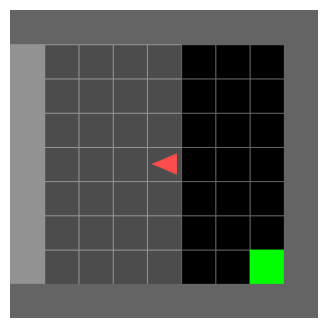

ep=43 t=36 a=forward probs=[0.047 0.017 0.936]


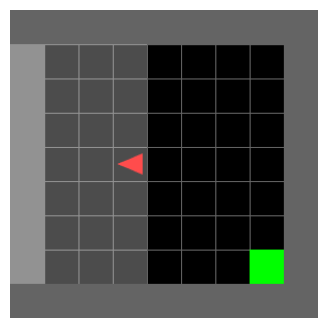

ep=43 t=37 a=forward probs=[0.056 0.025 0.92 ]


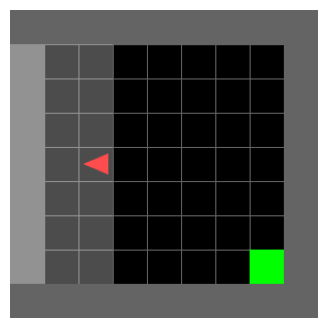

ep=43 t=38 a=forward probs=[0.067 0.035 0.898]


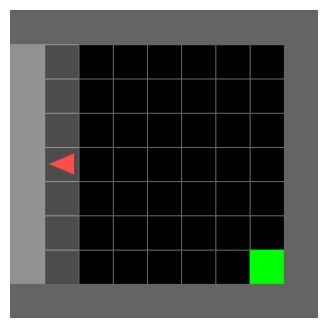

ep=43 t=39 a=forward probs=[0.067 0.035 0.898]


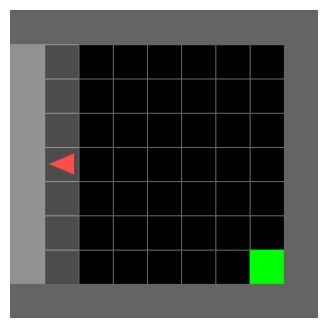

ep=43 t=40 a=forward probs=[0.067 0.035 0.898]


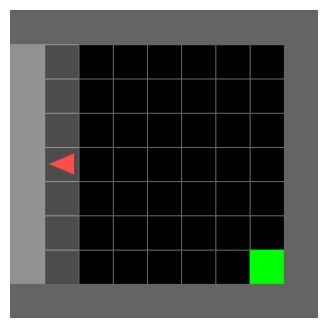

ep=43 t=41 a=forward probs=[0.067 0.035 0.898]


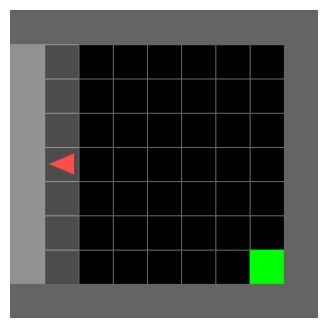

ep=43 t=42 a=forward probs=[0.067 0.035 0.898]


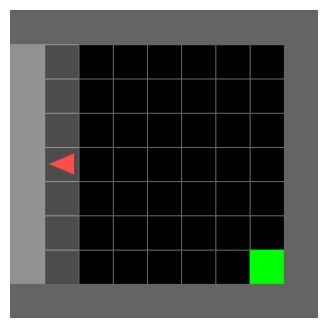

ep=43 t=43 a=forward probs=[0.067 0.035 0.898]


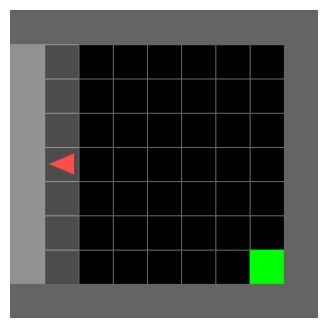

ep=43 t=44 a=forward probs=[0.067 0.035 0.898]


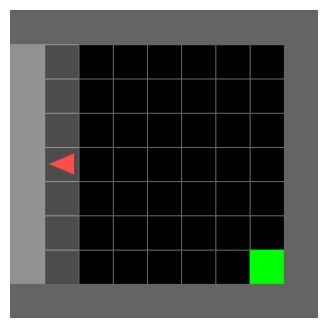

ep=43 t=45 a=forward probs=[0.067 0.035 0.898]


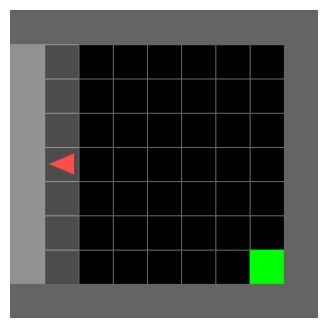

ep=43 t=46 a=forward probs=[0.067 0.035 0.898]


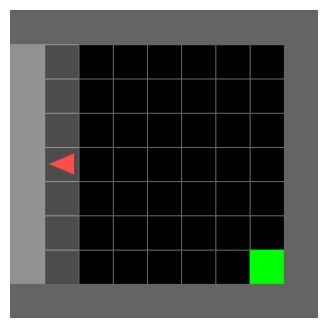

ep=43 t=47 a=forward probs=[0.067 0.035 0.898]


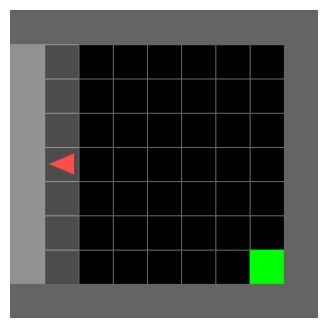

ep=43 t=48 a=right probs=[0.067 0.035 0.898]


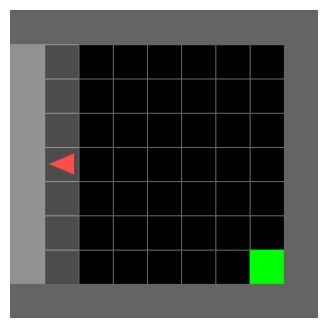

ep=43 t=49 a=forward probs=[0.025 0.014 0.961]


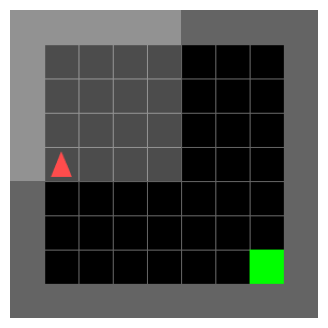

ep=43 t=50 a=forward probs=[0.068 0.036 0.896]


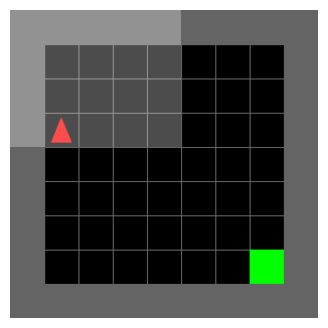

ep=43 t=51 a=forward probs=[0.064 0.037 0.9  ]


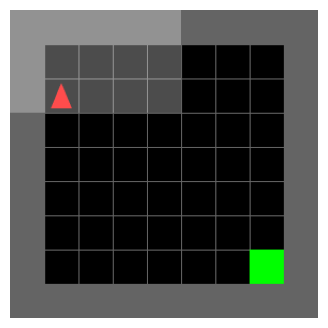

ep=43 t=52 a=left probs=[0.097 0.037 0.866]


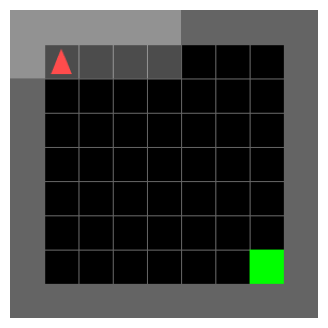

ep=43 t=53 a=forward probs=[0.061 0.044 0.895]


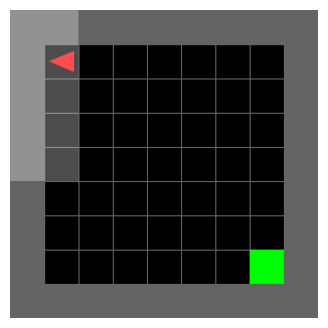

ep=43 t=54 a=forward probs=[0.061 0.044 0.895]


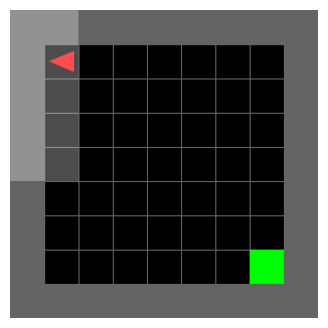

ep=43 t=55 a=forward probs=[0.061 0.044 0.895]


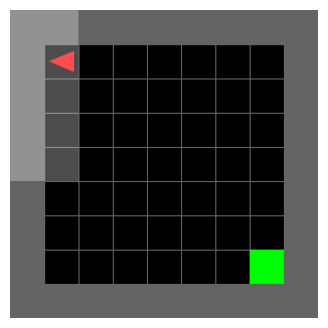

ep=43 t=56 a=forward probs=[0.061 0.044 0.895]


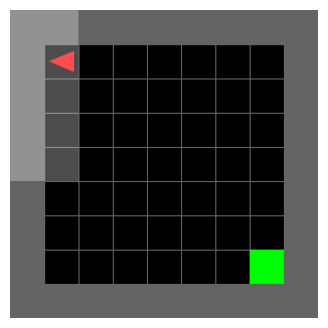

ep=43 t=57 a=forward probs=[0.061 0.044 0.895]


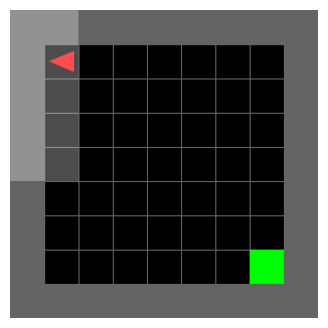

ep=43 t=58 a=right probs=[0.061 0.044 0.895]


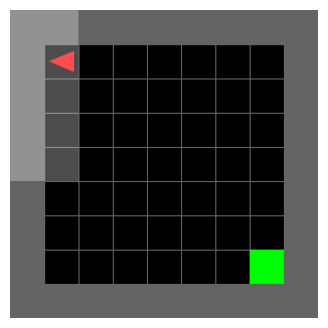

ep=43 t=59 a=forward probs=[0.097 0.037 0.866]


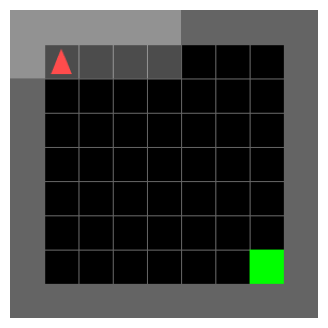

ep=43 t=60 a=forward probs=[0.097 0.037 0.866]


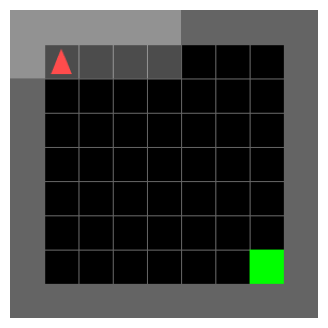

ep=43 t=61 a=forward probs=[0.097 0.037 0.866]


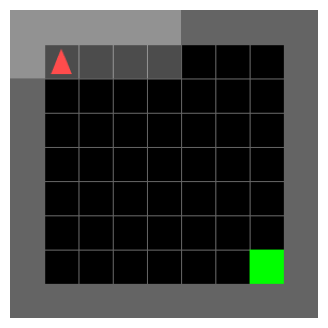

ep=43 t=62 a=forward probs=[0.097 0.037 0.866]


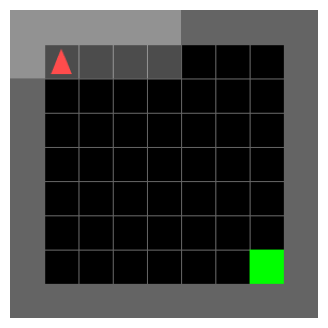

ep=43 t=63 a=right probs=[0.097 0.037 0.866]


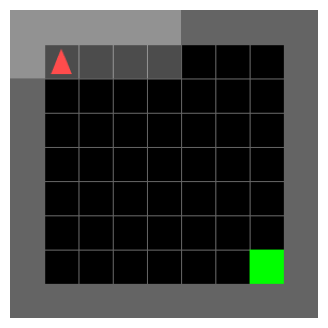

ep=43 t=64 a=forward probs=[0.095 0.038 0.867]


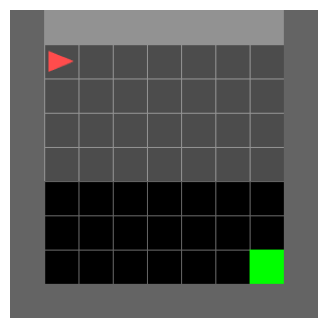

ep=43 t=65 a=forward probs=[0.116 0.057 0.827]


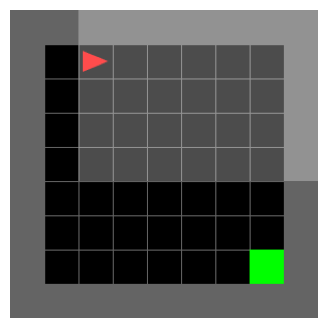

ep=43 t=66 a=forward probs=[0.117 0.03  0.853]


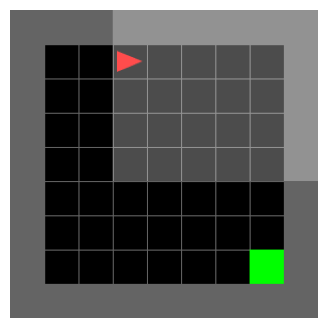

ep=43 t=67 a=forward probs=[0.106 0.028 0.866]


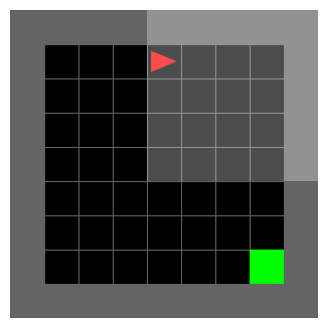

ep=43 t=68 a=forward probs=[0.092 0.018 0.89 ]


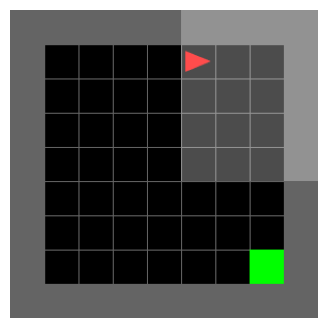

ep=43 t=69 a=forward probs=[0.039 0.03  0.931]


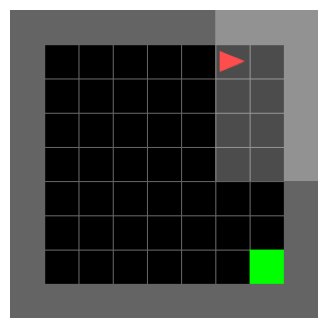

ep=43 t=70 a=forward probs=[0.097 0.049 0.854]


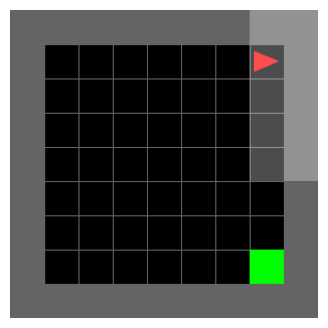

ep=43 t=71 a=forward probs=[0.097 0.049 0.854]


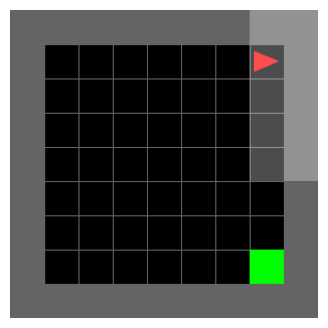

ep=43 t=72 a=forward probs=[0.097 0.049 0.854]


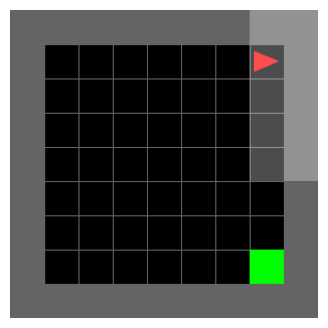

ep=43 t=73 a=left probs=[0.097 0.049 0.854]


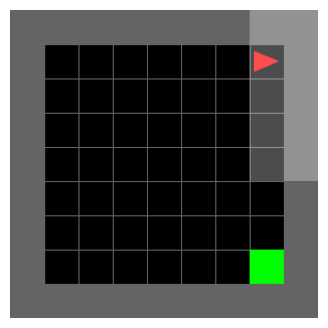

ep=43 t=74 a=forward probs=[0.046 0.023 0.931]


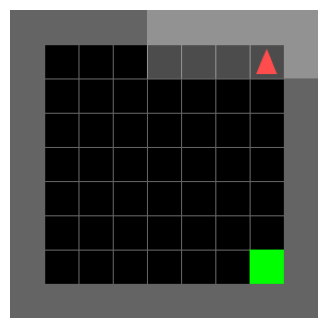

ep=43 t=75 a=forward probs=[0.046 0.023 0.931]


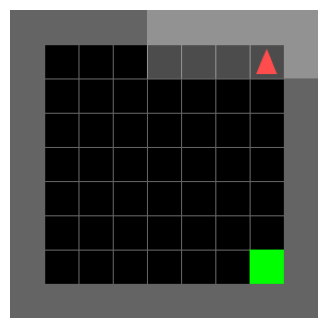

ep=43 t=76 a=forward probs=[0.046 0.023 0.931]


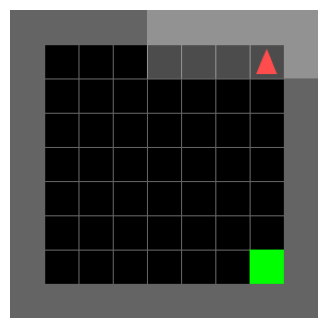

ep=43 t=77 a=forward probs=[0.046 0.023 0.931]


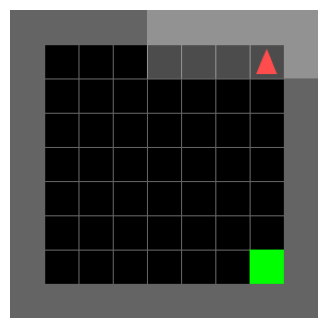

ep=43 t=78 a=forward probs=[0.046 0.023 0.931]


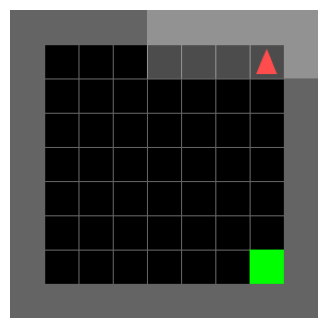

ep=43 t=79 a=forward probs=[0.046 0.023 0.931]


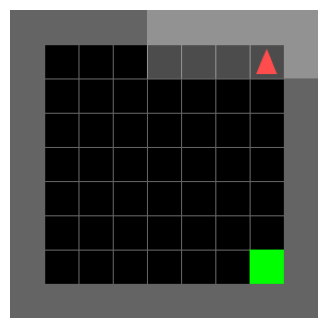

ep=43 t=80 a=left probs=[0.046 0.023 0.931]


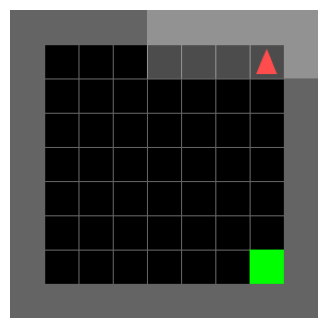

ep=43 t=81 a=forward probs=[0.109 0.049 0.842]


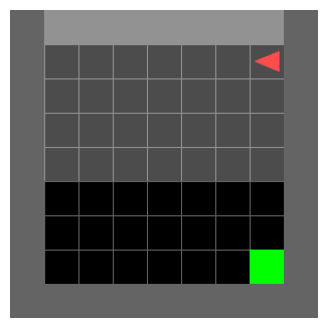

ep=43 t=82 a=forward probs=[0.055 0.074 0.871]


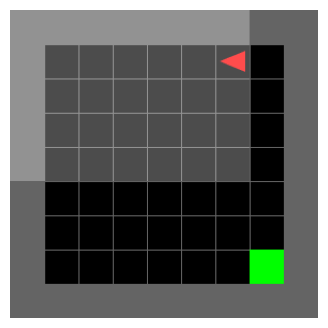

ep=43 t=83 a=forward probs=[0.068 0.033 0.899]


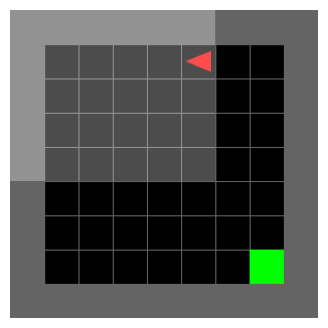

ep=43 t=84 a=forward probs=[0.045 0.028 0.927]


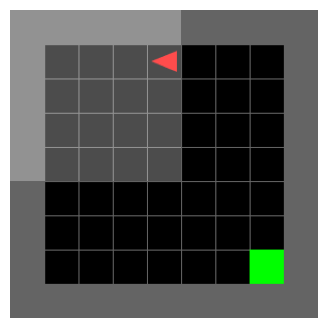

ep=43 t=85 a=forward probs=[0.062 0.031 0.907]


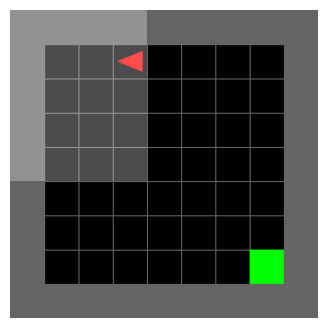

ep=43 t=86 a=forward probs=[0.031 0.028 0.941]


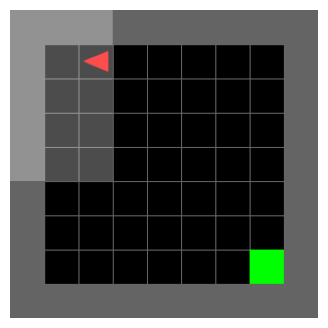

ep=43 t=87 a=forward probs=[0.061 0.044 0.895]


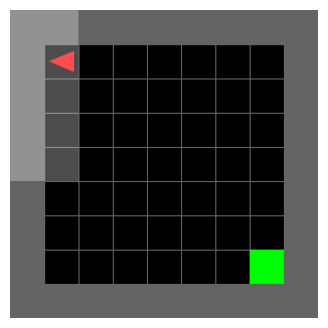

ep=43 t=88 a=left probs=[0.061 0.044 0.895]


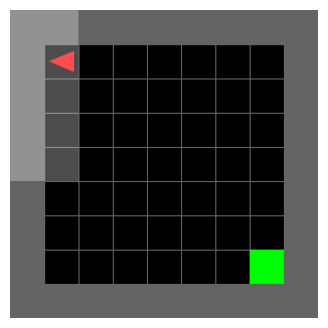

ep=43 t=89 a=right probs=[0.164 0.079 0.757]


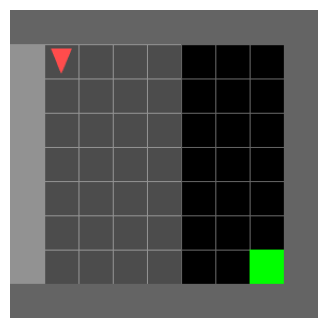

ep=43 t=90 a=forward probs=[0.061 0.044 0.895]


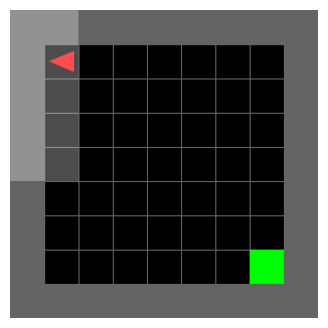

ep=43 t=91 a=right probs=[0.061 0.044 0.895]


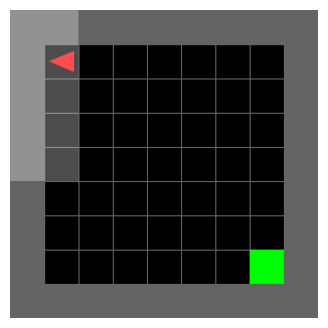

ep=43 t=92 a=forward probs=[0.097 0.037 0.866]


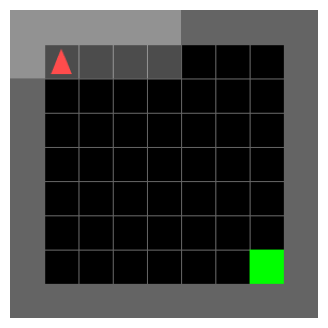

ep=43 t=93 a=forward probs=[0.097 0.037 0.866]


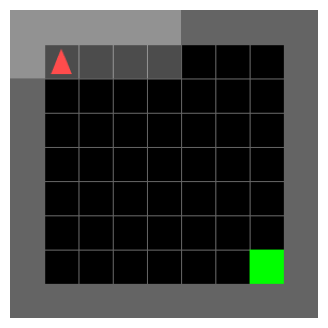

ep=43 t=94 a=right probs=[0.097 0.037 0.866]


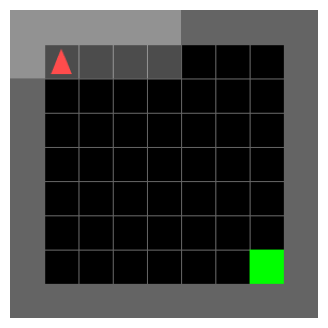

ep=43 t=95 a=forward probs=[0.095 0.038 0.867]


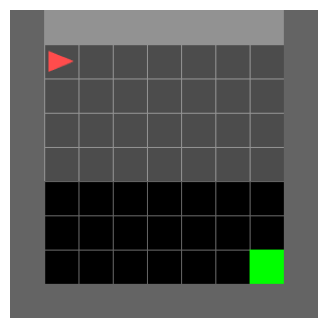

ep=43 t=96 a=forward probs=[0.116 0.057 0.827]


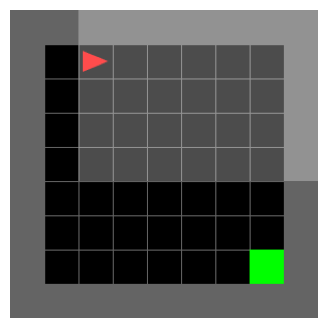

ep=43 t=97 a=forward probs=[0.117 0.03  0.853]


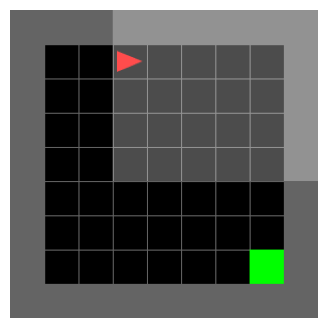

ep=43 t=98 a=forward probs=[0.106 0.028 0.866]


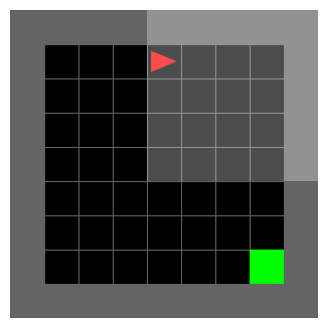

ep=43 t=99 a=forward probs=[0.092 0.018 0.89 ]


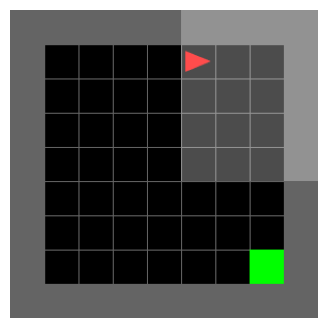

ep=43 t=100 a=forward probs=[0.039 0.03  0.931]


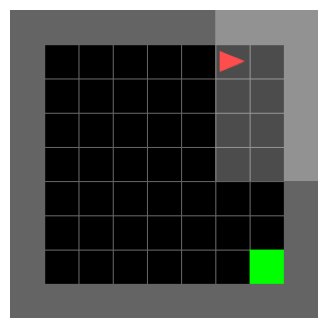

[EP 43] size=9 success=0 return=0.00 len=100
ep=44 t=1 a=forward probs=[0.039 0.03  0.931]


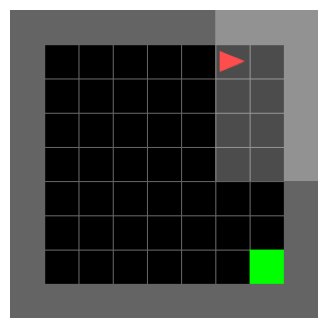

ep=44 t=2 a=left probs=[0.097 0.049 0.854]


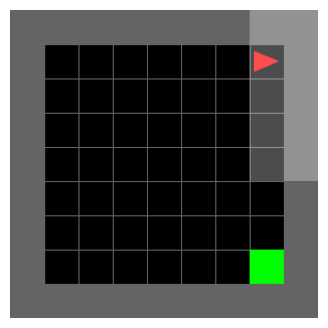

ep=44 t=3 a=right probs=[0.046 0.023 0.931]


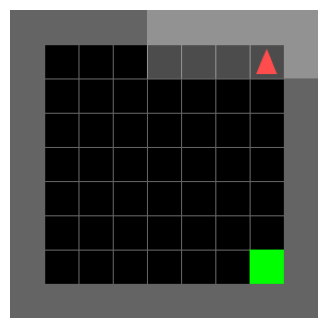

ep=44 t=4 a=forward probs=[0.097 0.049 0.854]


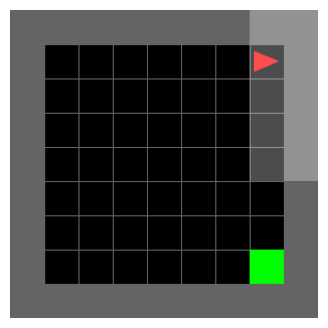

ep=44 t=5 a=forward probs=[0.097 0.049 0.854]


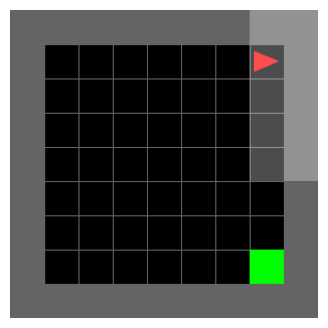

ep=44 t=6 a=right probs=[0.097 0.049 0.854]


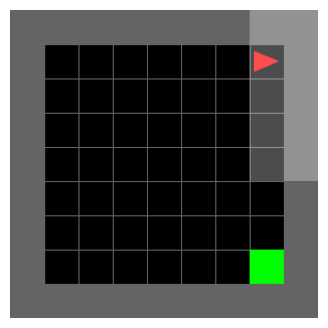

ep=44 t=7 a=forward probs=[0.067 0.041 0.892]


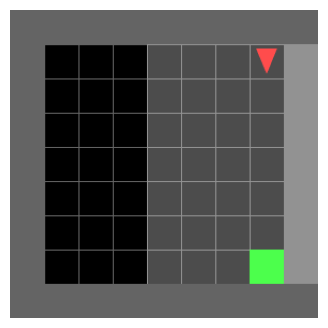

ep=44 t=8 a=forward probs=[0.059 0.043 0.898]


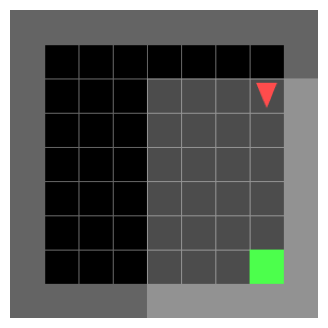

ep=44 t=9 a=forward probs=[0.098 0.062 0.84 ]


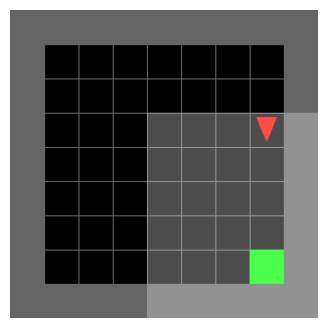

ep=44 t=10 a=forward probs=[0.097 0.07  0.833]


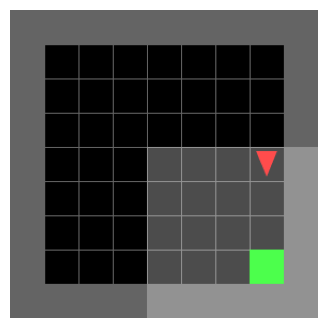

ep=44 t=11 a=forward probs=[0.079 0.031 0.89 ]


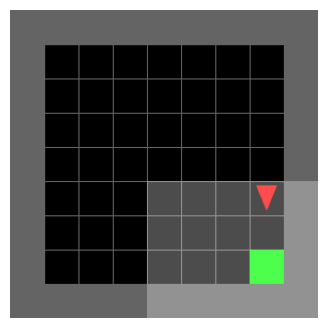

ep=44 t=12 a=forward probs=[0.047 0.04  0.913]


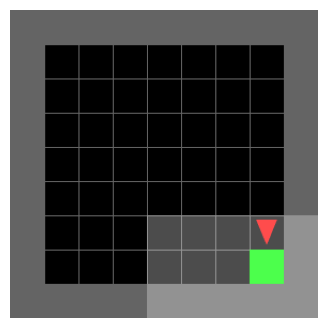

[EP 44] size=9 success=1 return=0.97 len=12
ep=45 t=1 a=forward probs=[0.075 0.034 0.891]


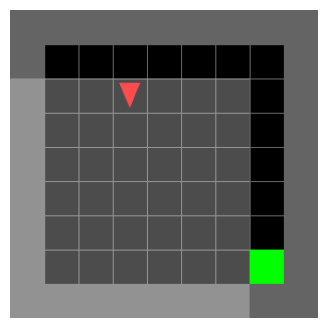

ep=45 t=2 a=forward probs=[0.044 0.033 0.923]


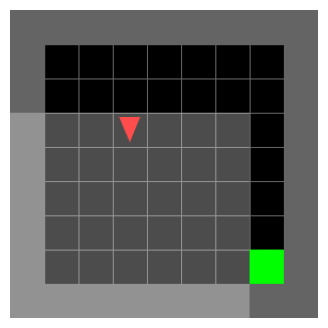

ep=45 t=3 a=forward probs=[0.045 0.015 0.94 ]


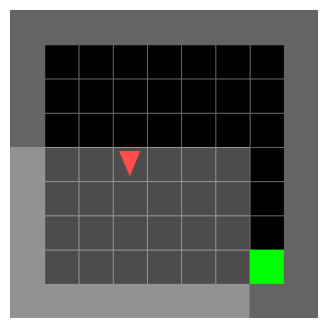

ep=45 t=4 a=forward probs=[0.062 0.047 0.89 ]


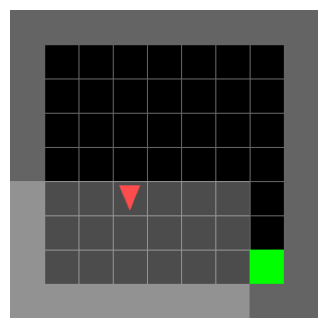

ep=45 t=5 a=forward probs=[0.09  0.039 0.871]


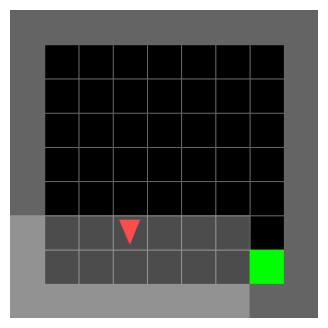

ep=45 t=6 a=forward probs=[0.061 0.012 0.927]


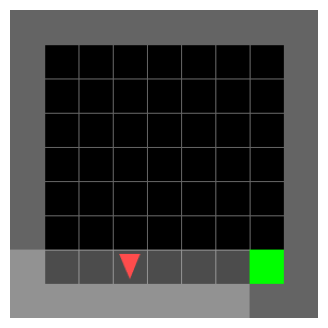

ep=45 t=7 a=forward probs=[0.061 0.012 0.927]


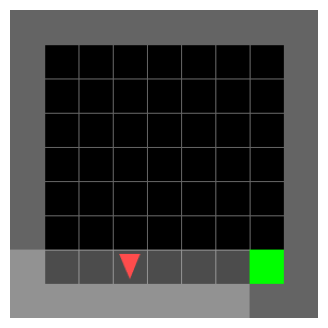

ep=45 t=8 a=forward probs=[0.061 0.012 0.927]


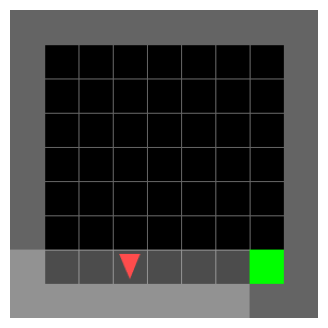

ep=45 t=9 a=forward probs=[0.061 0.012 0.927]


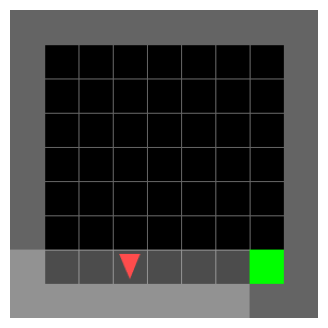

ep=45 t=10 a=forward probs=[0.061 0.012 0.927]


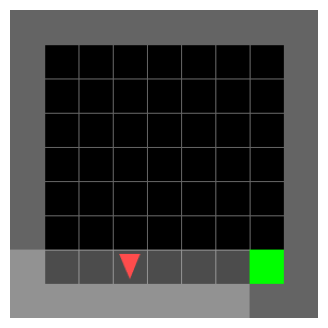

ep=45 t=11 a=forward probs=[0.061 0.012 0.927]


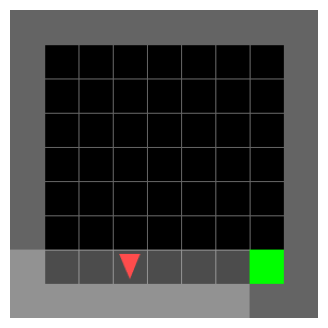

ep=45 t=12 a=forward probs=[0.061 0.012 0.927]


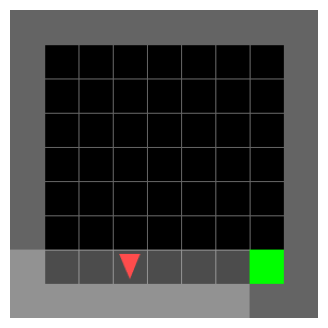

ep=45 t=13 a=forward probs=[0.061 0.012 0.927]


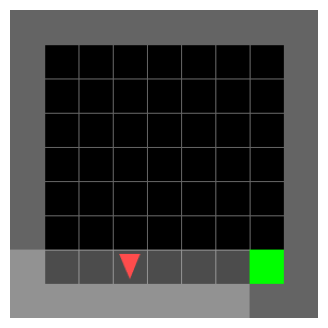

ep=45 t=14 a=forward probs=[0.061 0.012 0.927]


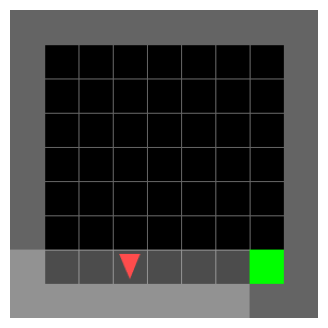

ep=45 t=15 a=forward probs=[0.061 0.012 0.927]


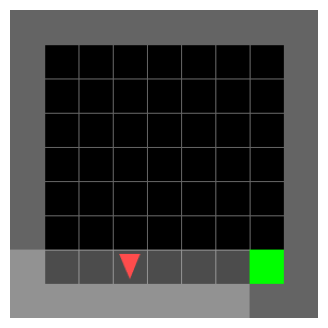

ep=45 t=16 a=forward probs=[0.061 0.012 0.927]


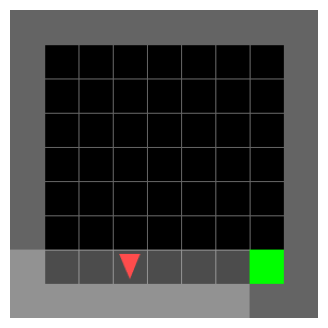

ep=45 t=17 a=forward probs=[0.061 0.012 0.927]


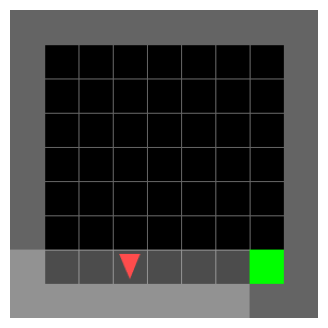

ep=45 t=18 a=forward probs=[0.061 0.012 0.927]


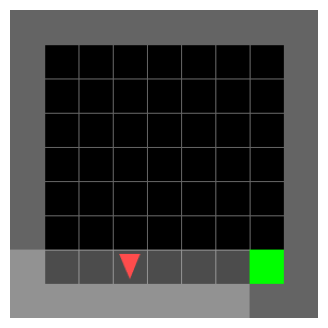

ep=45 t=19 a=forward probs=[0.061 0.012 0.927]


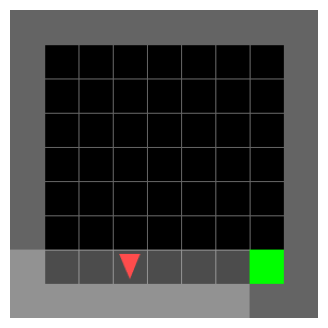

ep=45 t=20 a=forward probs=[0.061 0.012 0.927]


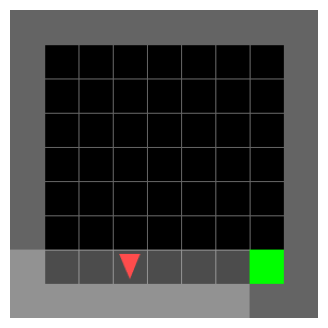

ep=45 t=21 a=forward probs=[0.061 0.012 0.927]


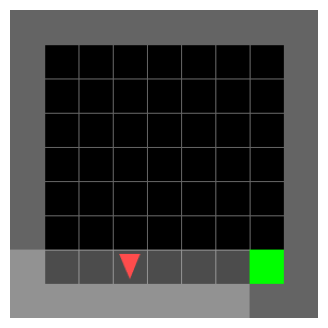

ep=45 t=22 a=left probs=[0.061 0.012 0.927]


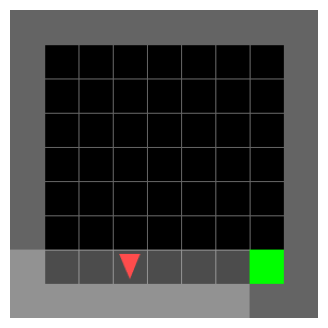

ep=45 t=23 a=forward probs=[0.066 0.022 0.912]


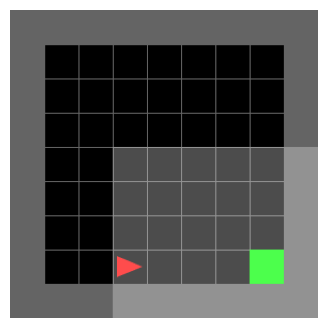

ep=45 t=24 a=forward probs=[0.032 0.022 0.946]


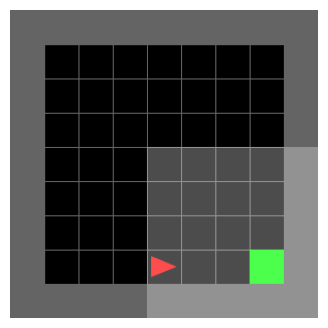

ep=45 t=25 a=forward probs=[0.032 0.03  0.938]


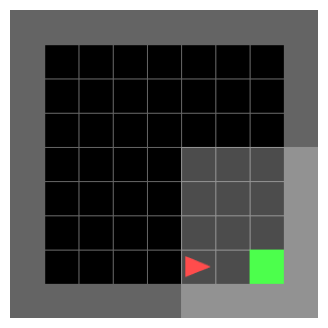

ep=45 t=26 a=forward probs=[0.054 0.027 0.919]


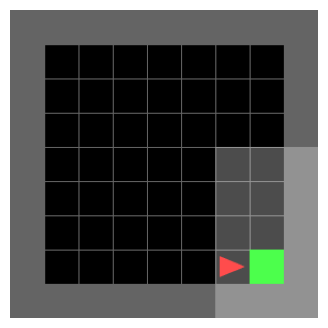

[EP 45] size=9 success=1 return=0.93 len=26
ep=46 t=1 a=forward probs=[0.073 0.042 0.885]


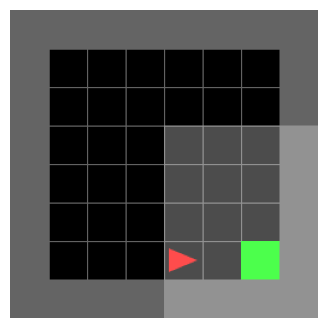

ep=46 t=2 a=forward probs=[0.042 0.052 0.906]


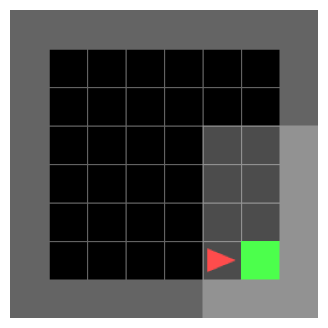

[EP 46] size=8 success=1 return=0.99 len=2
ep=47 t=1 a=forward probs=[0.041 0.02  0.939]


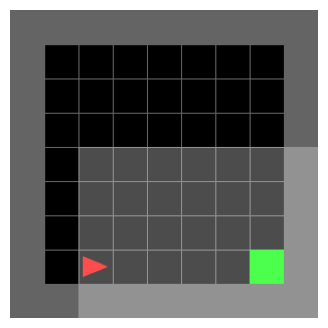

ep=47 t=2 a=forward probs=[0.066 0.022 0.912]


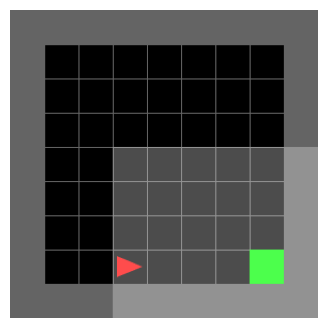

ep=47 t=3 a=forward probs=[0.032 0.022 0.946]


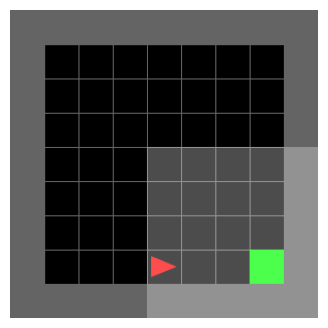

ep=47 t=4 a=forward probs=[0.032 0.03  0.938]


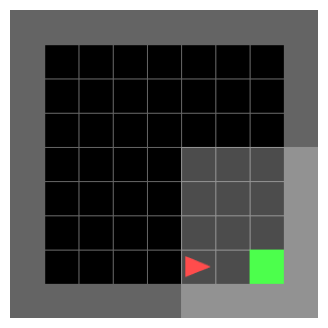

ep=47 t=5 a=forward probs=[0.054 0.027 0.919]


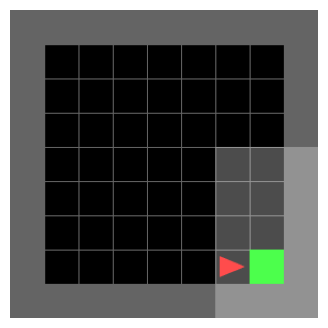

[EP 47] size=9 success=1 return=0.99 len=5
ep=48 t=1 a=left probs=[0.073 0.038 0.889]


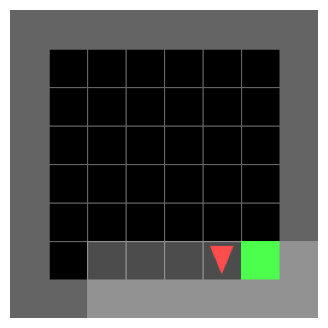

ep=48 t=2 a=forward probs=[0.042 0.052 0.906]


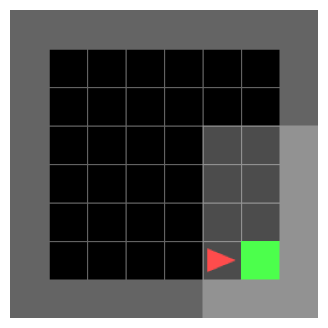

[EP 48] size=8 success=1 return=0.99 len=2
ep=49 t=1 a=forward probs=[0.137 0.053 0.81 ]


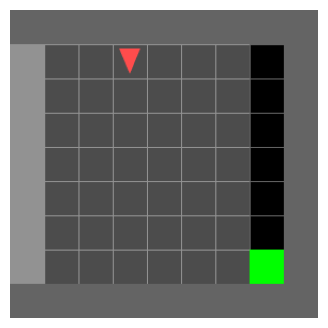

ep=49 t=2 a=forward probs=[0.075 0.034 0.891]


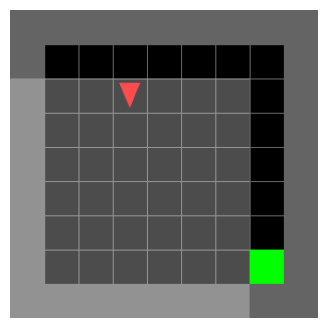

ep=49 t=3 a=forward probs=[0.044 0.033 0.923]


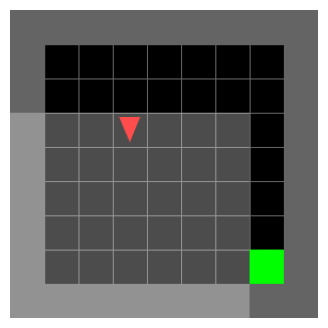

ep=49 t=4 a=forward probs=[0.045 0.015 0.94 ]


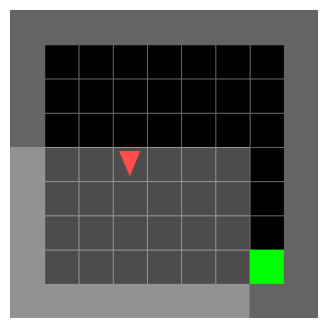

ep=49 t=5 a=forward probs=[0.062 0.047 0.89 ]


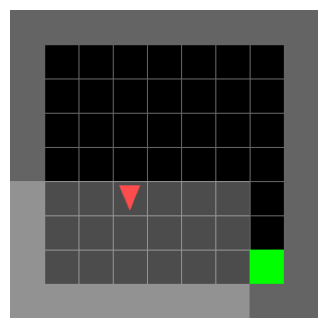

ep=49 t=6 a=forward probs=[0.09  0.039 0.871]


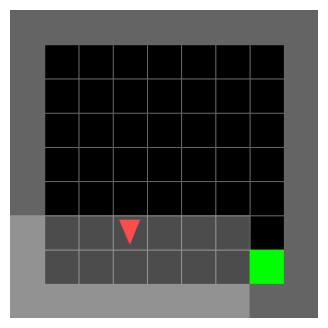

ep=49 t=7 a=forward probs=[0.061 0.012 0.927]


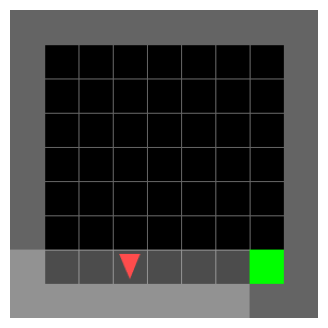

ep=49 t=8 a=forward probs=[0.061 0.012 0.927]


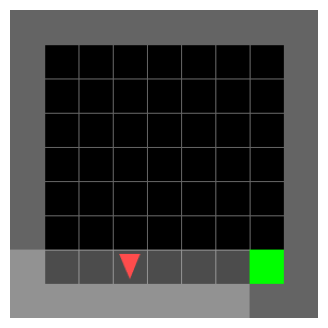

ep=49 t=9 a=forward probs=[0.061 0.012 0.927]


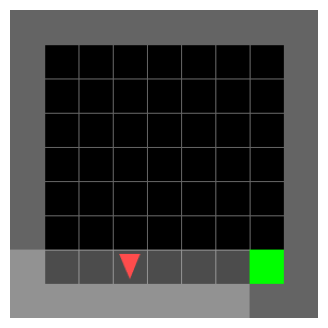

ep=49 t=10 a=forward probs=[0.061 0.012 0.927]


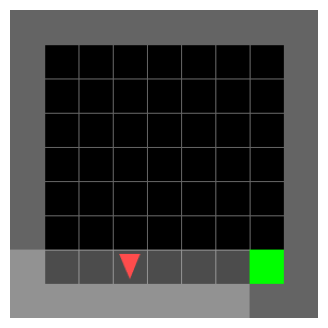

ep=49 t=11 a=forward probs=[0.061 0.012 0.927]


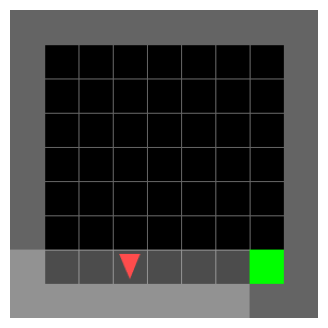

ep=49 t=12 a=forward probs=[0.061 0.012 0.927]


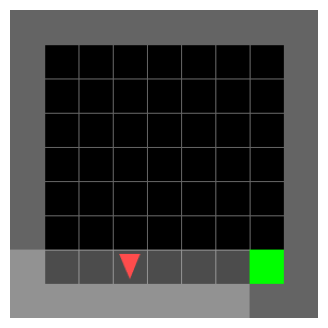

ep=49 t=13 a=forward probs=[0.061 0.012 0.927]


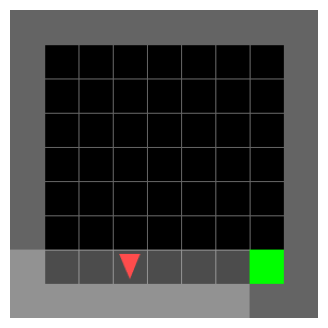

ep=49 t=14 a=left probs=[0.061 0.012 0.927]


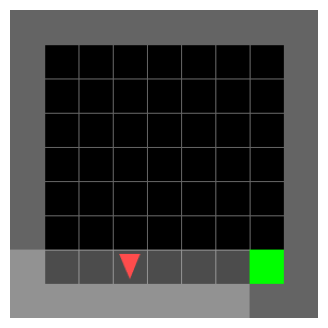

ep=49 t=15 a=forward probs=[0.066 0.022 0.912]


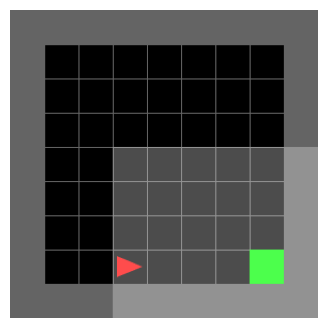

ep=49 t=16 a=forward probs=[0.032 0.022 0.946]


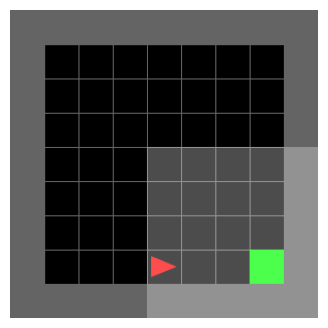

ep=49 t=17 a=forward probs=[0.032 0.03  0.938]


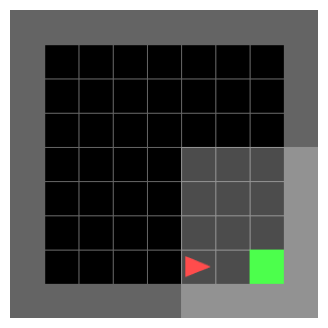

ep=49 t=18 a=left probs=[0.054 0.027 0.919]


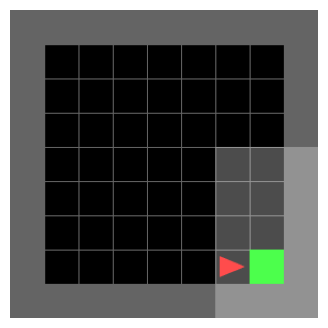

ep=49 t=19 a=forward probs=[0.027 0.014 0.959]


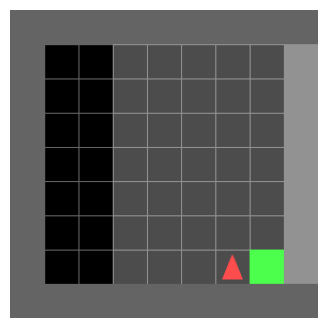

ep=49 t=20 a=forward probs=[0.054 0.012 0.934]


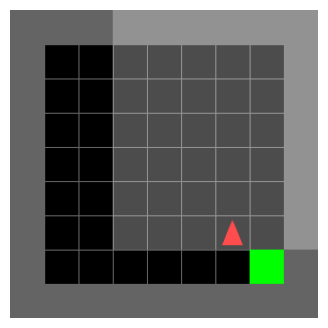

ep=49 t=21 a=forward probs=[0.07  0.019 0.911]


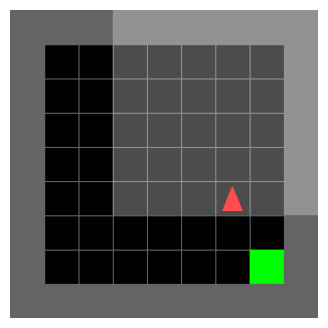

ep=49 t=22 a=forward probs=[0.047 0.031 0.922]


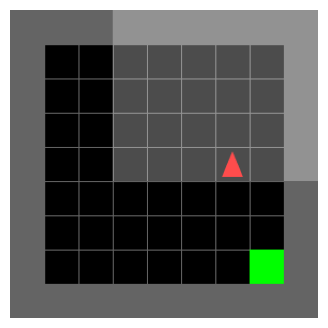

ep=49 t=23 a=forward probs=[0.085 0.024 0.891]


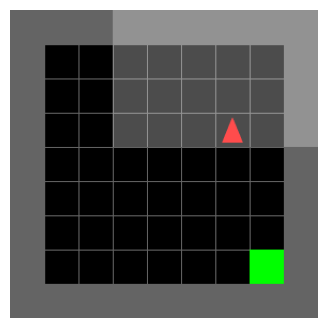

ep=49 t=24 a=forward probs=[0.045 0.021 0.934]


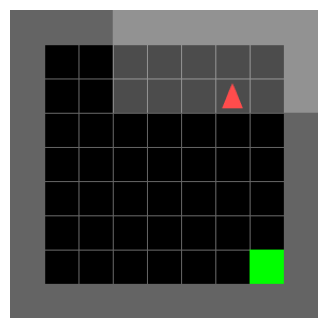

ep=49 t=25 a=left probs=[0.038 0.012 0.95 ]


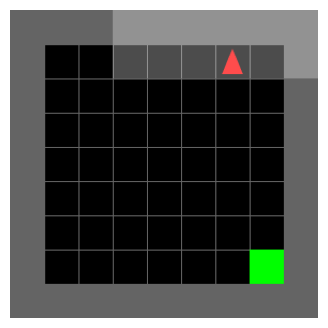

ep=49 t=26 a=forward probs=[0.055 0.074 0.871]


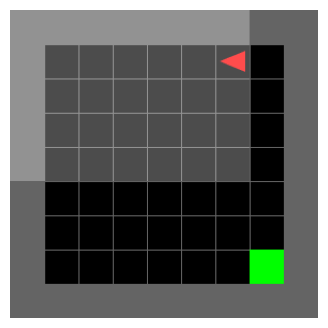

ep=49 t=27 a=forward probs=[0.068 0.033 0.899]


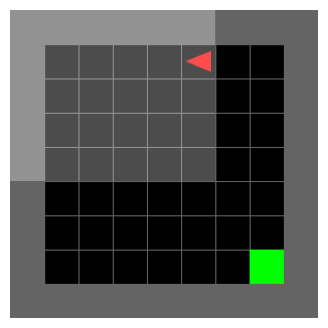

ep=49 t=28 a=left probs=[0.045 0.028 0.927]


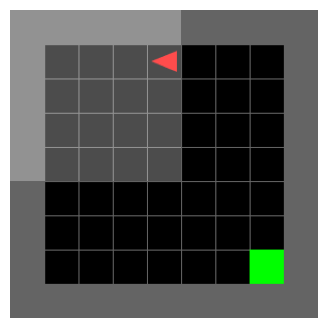

ep=49 t=29 a=forward probs=[0.023 0.022 0.955]


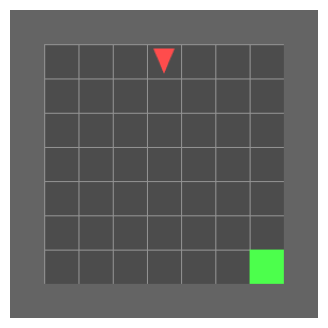

ep=49 t=30 a=forward probs=[0.085 0.033 0.882]


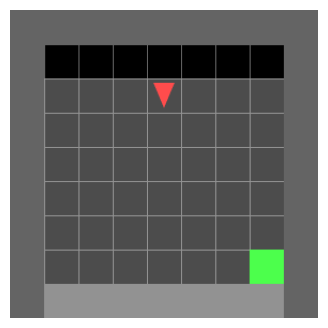

ep=49 t=31 a=forward probs=[0.072 0.035 0.893]


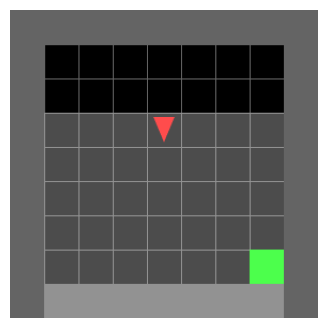

ep=49 t=32 a=forward probs=[0.045 0.015 0.94 ]


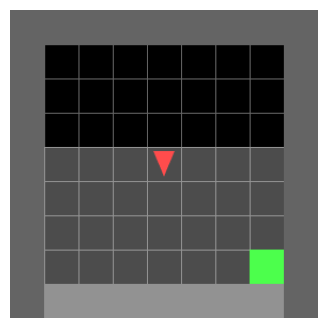

ep=49 t=33 a=forward probs=[0.068 0.025 0.907]


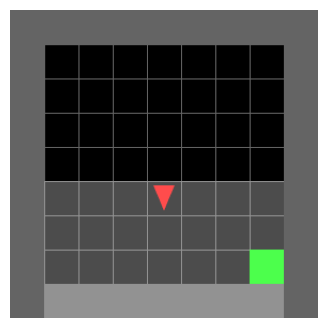

ep=49 t=34 a=forward probs=[0.092 0.04  0.868]


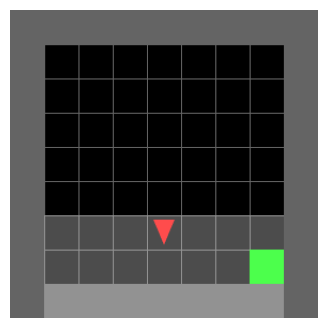

ep=49 t=35 a=forward probs=[0.049 0.02  0.931]


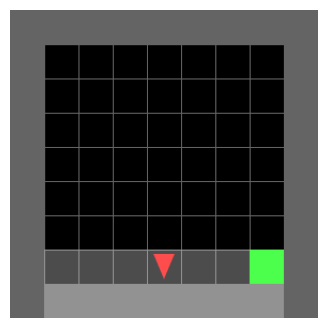

ep=49 t=36 a=left probs=[0.049 0.02  0.931]


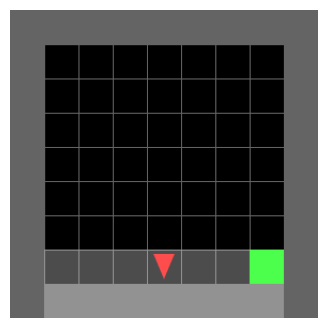

ep=49 t=37 a=forward probs=[0.032 0.022 0.946]


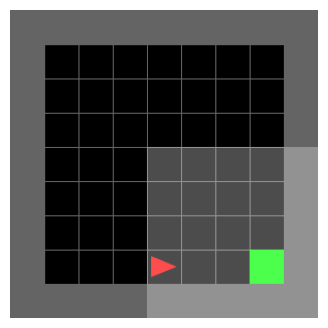

ep=49 t=38 a=forward probs=[0.032 0.03  0.938]


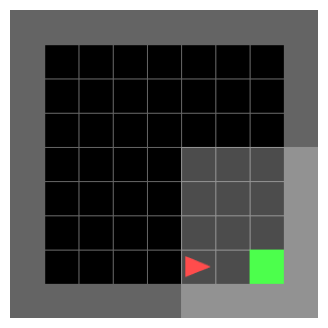

ep=49 t=39 a=forward probs=[0.054 0.027 0.919]


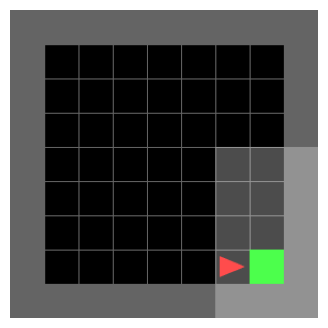

[EP 49] size=9 success=1 return=0.89 len=39

=== Summary ===
Success rate: 0.780 (39/50)
Avg return:   0.700
Avg length:   47.0


In [4]:
# sft unseen

run_eval(num_episodes=50, sizes=[8, 9], max_steps=100, render=True, seed=123, temperature=1.4, greedy=False, show_env = True) 

In [ ]:
# grpo 

run_eval(num_episodes=100, sizes=[8], max_steps=100, render=False, seed=123, temperature=1.8, greedy=False, show_env = False) 


[EP 0] size=8 success=1 return=0.86 len=39
[EP 1] size=8 success=1 return=0.99 len=4
[EP 2] size=8 success=1 return=0.69 len=87
[EP 3] size=8 success=1 return=1.00 len=1
[EP 4] size=8 success=1 return=0.95 len=14
[EP 5] size=8 success=1 return=0.98 len=7
[EP 6] size=8 success=0 return=0.00 len=100
[EP 7] size=8 success=1 return=0.94 len=16
[EP 8] size=8 success=1 return=0.91 len=25
[EP 9] size=8 success=1 return=0.80 len=58
[EP 10] size=8 success=1 return=0.85 len=44
[EP 11] size=8 success=1 return=0.94 len=16
[EP 12] size=8 success=1 return=0.82 len=50
[EP 13] size=8 success=0 return=0.00 len=100
[EP 14] size=8 success=1 return=0.81 len=55
[EP 15] size=8 success=1 return=0.84 len=45
[EP 16] size=8 success=1 return=0.80 len=58
[EP 17] size=8 success=1 return=0.92 len=24
[EP 18] size=8 success=1 return=0.67 len=93
[EP 19] size=8 success=1 return=0.93 len=19
[EP 20] size=8 success=1 return=0.89 len=32
[EP 21] size=8 success=1 return=0.91 len=26
[EP 22] size=8 success=1 return=0.96 len=11